# CS 639 Spring 2026 — HW 2: Transformers
**Due: March 10, 2026 11:59 pm**

In this notebook you will build a small GPT-style language model from scratch.

**Instructions:**
- Fill in all cells marked with `# TODO`.
- Do **not** modify the provided code unless instructed.
- Make sure to run on a **GPU runtime** (Runtime → Change runtime type → T4 GPU).
- Run the sanity checks after each part to help you debug. These are **not graded** — your submission will be evaluated by a separate hidden test suite on Gradescope.
- Submit this notebook (.ipynb with outputs) **and** a separate PDF writeup to Gradescope.

---
## Section 0: Setup & Data

#### Make sure you are using GPU. the output of the cell below shoud be: `Using device: cuda`

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time

# Hyperparameters
batch_size = 64
block_size = 256       # context length
n_embd = 128           # embedding dimension (d_model)
n_head = 4             # number of attention heads
n_layer = 4            # number of transformer blocks
dropout = 0.1
learning_rate = 3e-4
max_iters = 5000
eval_interval = 250
eval_iters = 200

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Download and prepare the Tiny Shakespeare dataset
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O shakespeare.txt

with open('shakespeare.txt', 'r') as f:
    text = f.read()

print(f'Dataset size: {len(text):,} characters')
print(f'First 200 characters:\n{text[:200]}')

Dataset size: 1,115,394 characters
First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


#### Oh look at that! We are going to train a mini LLM to speak like Shakespearean characters, and tokenize *each character*

In [3]:

# Character-level tokenizer
chars = sorted(list(set(text)))
print(chars)
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size}')
print(f'Characters: {"".join(chars)}')

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Train/val split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [4]:
# Data loading
def get_batch(split):
    """Generate a batch of (input, target) pairs."""
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss(model):
    """Estimate train and val loss over eval_iters batches."""
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

---
## Section 1: Building Blocks (Provided)

The following components are provided for you. **Read through them** to understand how they work — you will use them in your implementations. **Do not change them**

In [5]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network.

    A two-layer MLP with GELU activation, as used in GPT-2.
    The inner dimension is 4x the embedding dimension.

    Args:
        n_embd: Embedding dimension (d_model).
        dropout: Dropout rate.
    """
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def train_model(model, max_iters=max_iters, lr=learning_rate):
    """Training loop. Returns the model and a dict of logged losses."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    steps = []

    start_time = time.time()
    for iter in range(max_iters):
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss(model)
            elapsed = time.time() - start_time
            print(f'Step {iter:5d} | train loss {losses["train"]:.4f} | val loss {losses["val"]:.4f} | time {elapsed:.1f}s')
            train_losses.append(losses['train'].item())
            val_losses.append(losses['val'].item())
            steps.append(iter)

        xb, yb = get_batch('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    total_time = time.time() - start_time
    print(f'\nTraining complete in {total_time:.1f}s')

    return model, {'steps': steps, 'train': train_losses, 'val': val_losses}


def plot_losses(log, title='Training and Validation Loss'):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(8, 4))
    plt.plot(log['steps'], log['train'], label='Train')
    plt.plot(log['steps'], log['val'], label='Val')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

---
## Section 2: Part A — Core Transformer Implementation

Implement the three core components below. After each implementation, run the sanity check cell to help you debug.

### A1: Scaled Dot-Product Attention (15 pts) `[Code]`

Implement the attention mechanism:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$

where $M$ is the causal mask ($-\infty$ for positions that should not be attended to).

In [7]:
def scaled_dot_product_attention(Q, K, V, mask=None, dropout_p=0.0, training=True):
    """Compute scaled dot-product attention.

    Args:
        Q: Query tensor of shape (B, n_heads, T, d_k)
        K: Key tensor of shape (B, n_heads, T, d_k)
        V: Value tensor of shape (B, n_heads, T, d_k)
        mask: Boolean mask of shape (1, 1, T, T). True = MASKED (do not attend).
        dropout_p: Dropout probability applied to attention weights.
        training: Whether we are in training mode (affects dropout).

    Returns:
        output: (B, n_heads, T, d_k) attention output.
        attn_weights: (B, n_heads, T, T) attention weights (after softmax, before dropout).
    """
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
      scores = scores.masked_fill(mask, float('-inf'))
    attn_weights = F.softmax(scores, dim=-1)
    attn_weights = F.dropout(attn_weights, p=dropout_p, training=training)
    output = attn_weights @ V
    return output, attn_weights

In [8]:
# ---- Sanity Check: A1 (not graded) ----
print("Running A1 sanity checks...")

_B, _H, _T, _dk = 2, 4, 8, 32
_Q = torch.randn(_B, _H, _T, _dk)
_K = torch.randn(_B, _H, _T, _dk)
_V = torch.randn(_B, _H, _T, _dk)
_mask = torch.triu(torch.ones(_T, _T, dtype=torch.bool), diagonal=1).view(1, 1, _T, _T)

_out, _attn = scaled_dot_product_attention(_Q, _K, _V, mask=_mask, dropout_p=0.0, training=False)

assert _out.shape == (_B, _H, _T, _dk), f"Output shape wrong: {_out.shape}"
print("  ✓ Output shape correct")

assert _attn.shape == (_B, _H, _T, _T), f"Attention weights shape wrong: {_attn.shape}"
print("  ✓ Attention weights shape correct")

assert torch.allclose(_attn.sum(dim=-1), torch.ones(_B, _H, _T), atol=1e-5), \
    "Attention weights don't sum to 1"
print("  ✓ Attention weights sum to 1")

print("All A1 sanity checks passed!")

Running A1 sanity checks...
  ✓ Output shape correct
  ✓ Attention weights shape correct
  ✓ Attention weights sum to 1
All A1 sanity checks passed!


### A2: Multi-Head Attention (15 pts) `[Code]`

Implement multi-head attention: project to Q, K, V, split into heads, apply attention, concatenate, and project output.

In [9]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention.

    Args:
        n_embd: Embedding dimension (d_model).
        n_head: Number of attention heads.
        block_size: Maximum sequence length (used for causal mask).
        dropout: Dropout rate.
    """
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"

        self.n_head = n_head
        self.d_k = n_embd // n_head   # dimension per head
        self.n_embd = n_embd

        # TODO: Define the following linear layers:
        #   self.W_q - projects input to queries  (n_embd -> n_embd)
        #   self.W_k - projects input to keys     (n_embd -> n_embd)
        #   self.W_v - projects input to values   (n_embd -> n_embd)
        #   self.W_o - output projection           (n_embd -> n_embd)

        self.W_q = nn.Linear(n_embd, n_embd)
        self.W_k = nn.Linear(n_embd, n_embd)
        self.W_v = nn.Linear(n_embd, n_embd)
        self.W_o = nn.Linear(n_embd, n_embd)

        self.dropout = dropout

        # Causal mask: True = masked (upper triangular)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(block_size, block_size, dtype=torch.bool), diagonal=1)
                 .view(1, 1, block_size, block_size)
        )

    def forward(self, x):
        """Forward pass.

        Args:
            x: (B, T, n_embd) input tensor.

        Returns:
            output: (B, T, n_embd) attention output.
        """
        B, T, C = x.shape

        # TODO: Implement multi-head attention.
        Q = self.W_q(x).view(B, T, self.n_head, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_head, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_head, self.d_k).transpose(1, 2)

        attn_mask = self.mask[:, :, :T, :T]

        output, attn_weights = scaled_dot_product_attention(Q, K, V, mask=attn_mask, dropout_p=self.dropout, training=self.training)
        output = output.transpose(1, 2).contiguous().view(B, T, self.n_embd)
        output = self.W_o(output)

        return output

In [10]:
# ---- Sanity Check: A2 (not graded) ----
print("Running A2 sanity checks...")

_mha = MultiHeadAttention(n_embd=128, n_head=4, block_size=256, dropout=0.0)
_x = torch.randn(2, 16, 128)
_out = _mha(_x)

assert _out.shape == (2, 16, 128), f"Output shape wrong: {_out.shape}"
print("  ✓ Output shape correct")

_n_params = sum(p.numel() for p in _mha.parameters())
_expected = 4 * (128 * 128 + 128)
assert _n_params == _expected, f"Parameter count wrong: {_n_params} (expected {_expected})"
print("  ✓ Parameter count correct")

print("All A2 sanity checks passed!")

Running A2 sanity checks...
  ✓ Output shape correct
  ✓ Parameter count correct
All A2 sanity checks passed!


### A3: Transformer Block (15 pts) `[Code]`

Wire together Pre-LN attention and feed-forward sublayers with residual connections.

```
x ─→ LayerNorm ─→ MultiHeadAttention ─→ (+) ─→ LayerNorm ─→ FeedForward ─→ (+) ─→ output
│                                         ↑    │                              ↑
└─────────── residual ────────────────────┘    └──────── residual ────────────┘
```

In [11]:
class TransformerBlock(nn.Module):
    """A single transformer block (Pre-LN variant).

    Args:
        n_embd: Embedding dimension.
        n_head: Number of attention heads.
        block_size: Maximum sequence length.
        dropout: Dropout rate.
    """
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()

        # TODO: Define the following submodules:
        #   self.ln1  - first LayerNorm  (n_embd)
        #   self.attn - MultiHeadAttention (your implementation from A2)
        #   self.ln2  - second LayerNorm (n_embd)
        #   self.ffn  - FeedForward (provided above)
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)

    def forward(self, x):
        """Forward pass.

        Args:
            x: (B, T, n_embd) input tensor.

        Returns:
            (B, T, n_embd) output tensor.
        """
        # TODO: Implement the Pre-LN transformer block.
        # Two sublayers, each with: LayerNorm -> sublayer -> residual add
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))

        return x

In [12]:
# ---- Sanity Check: A3 (not graded) ----
print("Running A3 sanity checks...")

_block = TransformerBlock(n_embd=128, n_head=4, block_size=256, dropout=0.0)
_x = torch.randn(2, 16, 128)
_out = _block(_x)

assert _out.shape == (2, 16, 128), f"Output shape wrong: {_out.shape}"
print("  ✓ Output shape correct")

print("All A3 sanity checks passed!")

Running A3 sanity checks...
  ✓ Output shape correct
All A3 sanity checks passed!


### A4: GPT Forward Pass (10 pts) `[Code]`

Implement the `forward` method of the `GPT` class. We provide `__init__` (which defines all layers), `_init_weights`, and `generate`. Your forward pass should:

1. Look up token embeddings and positional embeddings, add them together, and apply dropout.
2. Pass through the stack of transformer blocks.
3. Apply the final LayerNorm and the language model head to produce logits.
4. If targets are provided, compute the cross-entropy loss.

In [13]:
class GPT(nn.Module):
    """A small GPT language model."""
    def __init__(self, vocab_size, n_embd, block_size, n_head, n_layer, dropout):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)
        print(f'Model parameters: {sum(p.numel() for p in self.parameters()):,}')

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """Forward pass.

        Args:
            idx: (B, T) tensor of token indices.
            targets: (B, T) tensor of target token indices, or None.

        Returns:
            logits: (B, T, vocab_size) prediction scores.
            loss: scalar cross-entropy loss if targets provided, else None.
        """
        B, T = idx.shape

        # TODO: Implement the GPT forward pass.
        token_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        final_emb = token_emb + pos_emb
        x = self.drop(final_emb)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        else:
          loss = None

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [14]:
# ---- Sanity Check: A4 (not graded) ----
print("Running A4 sanity checks...")

_model = GPT(vocab_size, n_embd, block_size, n_head, n_layer, dropout).to(device)

_xb, _yb = get_batch('train')
_logits, _loss = _model(_xb, _yb)

assert _logits.shape == (batch_size, block_size, vocab_size), \
    f"Logits shape wrong: {_logits.shape}, expected {(batch_size, block_size, vocab_size)}"
print("  ✓ Logits shape correct")

assert _loss is not None, "Loss should not be None when targets are provided"
assert abs(_loss.item() - math.log(vocab_size)) < 0.5, \
    f"Initial loss {_loss.item():.2f} is far from expected ~{math.log(vocab_size):.2f} (random baseline)"
print(f"  ✓ Initial loss {_loss.item():.2f} (expected ~{math.log(vocab_size):.2f})")

_logits_no_loss, _no_loss = _model(_xb)
assert _no_loss is None, "Loss should be None when targets are not provided"
print("  ✓ Loss is None when no targets")

print("All A4 sanity checks passed!")

Running A4 sanity checks...
Model parameters: 842,817
  ✓ Logits shape correct
  ✓ Initial loss 4.16 (expected ~4.17)
  ✓ Loss is None when no targets
All A4 sanity checks passed!


### A5: Training and Validation (5 pts) `[Both]`

Run the cells below to train your model. If your implementation is correct, you should reach a **validation loss around or below 1.5** after 5000 steps.

**In your writeup, include:**
1. Your training and validation loss curves (screenshot the plot below).
2. Your final validation loss.
3. A sample of generated text (at least 200 characters).

In [15]:
# Build and verify the full model
model = GPT(vocab_size, n_embd, block_size, n_head, n_layer, dropout).to(device)

# Quick forward pass test
xb, yb = get_batch('train')
logits, loss = model(xb, yb)
print(f'Output shape: {logits.shape}')    # should be (64, 256, 65)
print(f'Initial loss: {loss.item():.4f}')  # should be ~4.17 (= -ln(1/65))

Model parameters: 842,817
Output shape: torch.Size([64, 256, 65])
Initial loss: 4.1944


### The moment we've been waiting for.. lets start training! (Note: this training will take ~11 minutes on the free T4 GPU)

In [16]:
# Train!
model, log = train_model(model)

Step     0 | train loss 4.1937 | val loss 4.1959 | time 11.8s
Step   250 | train loss 2.4584 | val loss 2.4608 | time 45.3s
Step   500 | train loss 2.2384 | val loss 2.2586 | time 78.3s
Step   750 | train loss 2.0005 | val loss 2.0601 | time 110.9s
Step  1000 | train loss 1.8137 | val loss 1.9234 | time 144.2s
Step  1250 | train loss 1.6925 | val loss 1.8425 | time 176.9s
Step  1500 | train loss 1.6142 | val loss 1.7843 | time 209.9s
Step  1750 | train loss 1.5610 | val loss 1.7372 | time 242.9s
Step  2000 | train loss 1.5180 | val loss 1.7017 | time 275.7s
Step  2250 | train loss 1.4844 | val loss 1.6771 | time 308.4s
Step  2500 | train loss 1.4553 | val loss 1.6548 | time 341.1s
Step  2750 | train loss 1.4347 | val loss 1.6276 | time 374.0s
Step  3000 | train loss 1.4158 | val loss 1.6162 | time 406.9s
Step  3250 | train loss 1.3972 | val loss 1.6000 | time 439.9s
Step  3500 | train loss 1.3811 | val loss 1.5908 | time 472.9s
Step  3750 | train loss 1.3703 | val loss 1.5824 | time 50

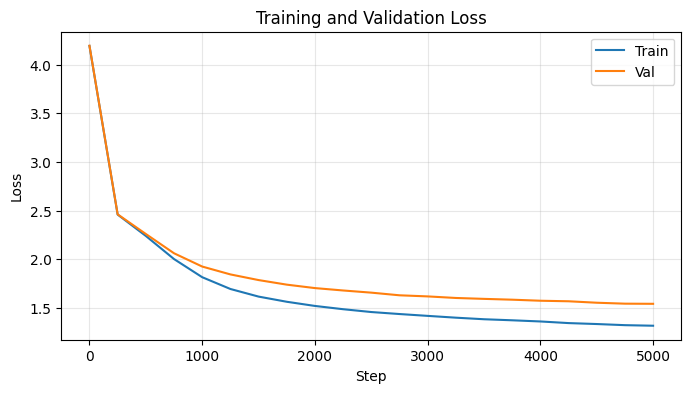

In [17]:
# Plot loss curves (include this plot in your writeup)
plot_losses(log)

In [18]:
# Generate text (include this output in your writeup)
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=500, temperature=0.8)
print(decode(generated[0].tolist()))



ISABELLA:
Why, is the prince with you speak.
So this hand the lad on grans to them that
Thy thight brother hath made of my betweet,
By the peace of this their whom of Warwick,
'With these death that beding for the crown,
And the kink to se proud by to bounds well.

TYORK:
The parin's proud be stop'd good in His revenge,
And thou flatter's be foltaly lifely?

KING HENRY VI


WARWICK:
How thy desire it, and at for seem shall wash
To that when to his dear?

Sewn:
Ay, sin! I have loved my brother w


### If your implementation is correct, you should see something resembling Shakespearean dialogue!

In [19]:
final_losses = estimate_loss(model)
print(f'Final val loss: {final_losses["val"]:.4f}')

Final val loss: 1.5451


---
## Section 3: Part B — Ablation Studies (10 pts)

In this part, you will run ablation experiments to understand how key architectural choices affect your GPT model. For each experiment, you will modify one hyperparameter, retrain, and compare.

Each ablation uses **2000 iterations** to keep training time manageable (~4 min per run).

In [20]:
def run_ablation(name, n_head_abl=n_head, n_layer_abl=n_layer, n_embd_abl=n_embd,
                 block_size_abl=block_size, max_iters_abl=2000):
    """Train a model with the given config and return the loss log.

    All hyperparameters default to the Part A values unless overridden.
    """
    print(f'\n{"="*60}')
    print(f'Ablation: {name}')
    print(f'  n_head={n_head_abl}, n_layer={n_layer_abl}, n_embd={n_embd_abl}, block_size={block_size_abl}')
    print(f'{"="*60}')

    abl_model = GPT(
        vocab_size, n_embd_abl, block_size_abl, n_head_abl, n_layer_abl, dropout
    ).to(device)

    _, abl_log = train_model(abl_model, max_iters=max_iters_abl, lr=learning_rate)
    return abl_log


def plot_ablation(logs, title, label_key='name'):
    """Plot multiple validation loss curves on a single figure.

    Args:
        logs: dict mapping config name -> loss log dict
        title: plot title
    """
    plt.figure(figsize=(8, 4))
    for name, log in logs.items():
        plt.plot(log['steps'], log['val'], label=name)
    plt.xlabel('Step')
    plt.ylabel('Validation Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print final val losses
    print('Final validation losses:')
    for name, log in logs.items():
        print(f'  {name}: {log["val"][-1]:.4f}')

### B1: Varying Number of Attention Heads (5 pts) `[Writeup]`

Train three models with different numbers of attention heads, keeping $d_{\text{model}} = 128$ fixed:
- 1 head ($d_k = 128$)
- 4 heads ($d_k = 32$) — the default
- 8 heads ($d_k = 16$)

**In your writeup:** (a) include the combined plot, (b) report final val losses, (c) in 2–3 sentences, discuss how the number of heads affects performance and why.

In [21]:
# B1: Vary number of heads
head_logs = {}
for h in [1, 4, 8]:
    head_logs[f'{h} head{"s" if h > 1 else ""}'] = run_ablation(
        f'{h} head{"s" if h > 1 else ""}', n_head_abl=h
    )


Ablation: 1 head
  n_head=1, n_layer=4, n_embd=128, block_size=256
Model parameters: 842,817
Step     0 | train loss 4.2296 | val loss 4.2286 | time 8.1s
Step   250 | train loss 2.4629 | val loss 2.4672 | time 30.6s
Step   500 | train loss 2.2508 | val loss 2.2699 | time 53.4s
Step   750 | train loss 1.9707 | val loss 2.0438 | time 75.6s
Step  1000 | train loss 1.7728 | val loss 1.8942 | time 98.0s
Step  1250 | train loss 1.6607 | val loss 1.8084 | time 121.5s
Step  1500 | train loss 1.5883 | val loss 1.7513 | time 144.2s
Step  1750 | train loss 1.5443 | val loss 1.7173 | time 166.9s
Step  1999 | train loss 1.4977 | val loss 1.6775 | time 189.9s

Training complete in 189.9s

Ablation: 4 heads
  n_head=4, n_layer=4, n_embd=128, block_size=256
Model parameters: 842,817
Step     0 | train loss 4.1750 | val loss 4.1706 | time 12.1s
Step   250 | train loss 2.4654 | val loss 2.4741 | time 45.0s
Step   500 | train loss 2.2759 | val loss 2.2946 | time 77.8s
Step   750 | train loss 2.0254 | va

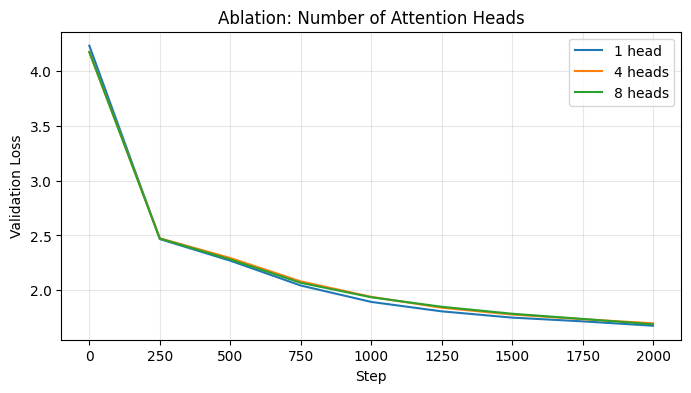

Final validation losses:
  1 head: 1.6775
  4 heads: 1.6993
  8 heads: 1.6907


In [22]:
# Plot B1 results (include this in your writeup)
plot_ablation(head_logs, 'Ablation: Number of Attention Heads')

### B2: Varying Number of Layers (5 pts) `[Writeup]`

Train three models with different depths, keeping all other hyperparameters at their defaults:
- 1 layer
- 2 layers
- 4 layers — the default

**In your writeup:** (a) include the combined plot, (b) report final val losses, (c) in 2–3 sentences, discuss the effect of depth and attention head scaling on performance.

In [23]:
# B2: Vary number of layers
layer_logs = {}
for l in [1, 2, 4]:
    layer_logs[f'{l} layer{"s" if l > 1 else ""}'] = run_ablation(
        f'{l} layer{"s" if l > 1 else ""}', n_layer_abl=l
    )


Ablation: 1 layer
  n_head=4, n_layer=1, n_embd=128, block_size=256
Model parameters: 248,001
Step     0 | train loss 4.2107 | val loss 4.2068 | time 3.8s
Step   250 | train loss 2.4823 | val loss 2.4901 | time 12.8s
Step   500 | train loss 2.3721 | val loss 2.3946 | time 21.9s
Step   750 | train loss 2.2048 | val loss 2.2565 | time 31.1s
Step  1000 | train loss 2.0673 | val loss 2.1539 | time 40.3s
Step  1250 | train loss 1.9244 | val loss 2.0427 | time 49.4s
Step  1500 | train loss 1.8012 | val loss 1.9371 | time 58.5s
Step  1750 | train loss 1.7204 | val loss 1.8704 | time 67.7s
Step  1999 | train loss 1.6645 | val loss 1.8243 | time 76.9s

Training complete in 76.9s

Ablation: 2 layers
  n_head=4, n_layer=2, n_embd=128, block_size=256
Model parameters: 446,273
Step     0 | train loss 4.2086 | val loss 4.2073 | time 6.5s
Step   250 | train loss 2.4769 | val loss 2.4849 | time 23.4s
Step   500 | train loss 2.3393 | val loss 2.3524 | time 40.5s
Step   750 | train loss 2.1575 | val lo

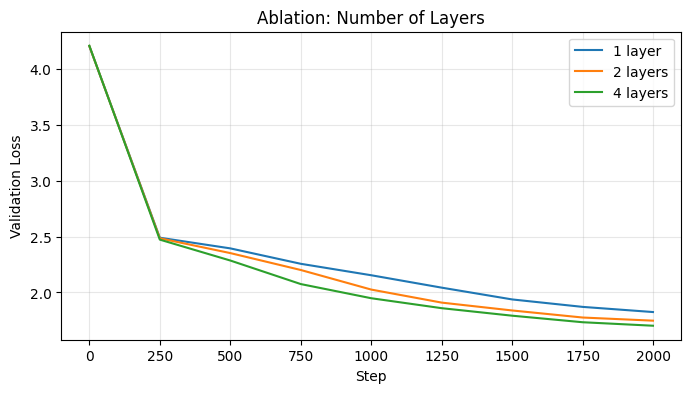

Final validation losses:
  1 layer: 1.8243
  2 layers: 1.7470
  4 layers: 1.7018


In [24]:
# Plot B2 results (include this in your writeup)
plot_ablation(layer_logs, 'Ablation: Number of Layers')

---
## Section 4: Part C — Tokenization & Positional Encoding (20 pts)

In this part, you will explore two important design choices: tokenization and positional encoding.

### C1: Character-Level vs. Word-Level Tokenization (5 pts) `[Writeup]`

In Part A, you trained a character-level model (vocab size = 65). An alternative is **word-level tokenization**, where each token is a whitespace-separated word.

**There is no code to write here** — we provide the word-level tokenizer and training code below. Just run the cells and analyze the results in your writeup.

In [25]:
# Word-level tokenizer
words = text.split()
word_vocab = sorted(list(set(words)))
word_vocab_size = len(word_vocab)

word_stoi = {w: i for i, w in enumerate(word_vocab)}
word_itos = {i: w for i, w in enumerate(word_vocab)}
word_encode = lambda s: [word_stoi[w] for w in s.split()]
word_decode = lambda l: ' '.join([word_itos[i] for i in l])

print(f'Character-level vocab size: {vocab_size}')
print(f'Word-level vocab size: {word_vocab_size}')
print(f'\nSample word tokens: {word_vocab[:20]}')

# Compare sequence lengths
char_tokens = encode(text)
word_tokens = word_encode(text)
print(f'\nTotal character tokens: {len(char_tokens):,}')
print(f'Total word tokens: {len(word_tokens):,}')
print(f'Compression ratio: {len(char_tokens) / len(word_tokens):.1f}x')

Character-level vocab size: 65
Word-level vocab size: 25670

Sample word tokens: ['&C:', '&c.', "'", "'?", "'A", "'Alas,", "'Alas,'", "'Alla", "'An", "'Ay", "'Ay,", "'Ay,'", "'Ay.'", "'Be", "'Beseech", "'Bless", "'Bove", "'Brutus!'", "'By", "'Charge"]

Total character tokens: 1,115,394
Total word tokens: 202,651
Compression ratio: 5.5x


In [26]:
# Prepare word-level data and training utilities
word_data = torch.tensor(word_tokens, dtype=torch.long)
word_n = int(0.9 * len(word_data))
word_train_data = word_data[:word_n]
word_val_data = word_data[word_n:]

word_block_size = 256  # same context window

def get_batch_word(split):
    d = word_train_data if split == 'train' else word_val_data
    ix = torch.randint(len(d) - word_block_size, (batch_size,))
    x = torch.stack([d[i:i+word_block_size] for i in ix])
    y = torch.stack([d[i+1:i+word_block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss_word(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch_word(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def train_model_word(model, max_iters=2000, lr=learning_rate):
    """Training loop for word-level model."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    train_losses, val_losses, steps = [], [], []
    start_time = time.time()
    for iter in range(max_iters):
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss_word(model)
            elapsed = time.time() - start_time
            print(f'Step {iter:5d} | train loss {losses["train"]:.4f} | val loss {losses["val"]:.4f} | time {elapsed:.1f}s')
            train_losses.append(losses['train'].item())
            val_losses.append(losses['val'].item())
            steps.append(iter)
        xb, yb = get_batch_word('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    total_time = time.time() - start_time
    print(f'\nTraining complete in {total_time:.1f}s')
    return model, {'steps': steps, 'train': train_losses, 'val': val_losses}

In [27]:
# Train word-level model (same architecture, just different vocab size)
print('Training word-level model...')
word_model = GPT(
    word_vocab_size, n_embd, word_block_size, n_head, n_layer, dropout
).to(device)

word_model, word_log = train_model_word(word_model, max_iters=1000)

Training word-level model...
Model parameters: 7,423,302
Step     0 | train loss 10.1729 | val loss 10.1682 | time 36.1s
Step   250 | train loss 6.4088 | val loss 7.3970 | time 136.6s
Step   500 | train loss 5.2326 | val loss 7.4229 | time 237.6s
Step   750 | train loss 3.8519 | val loss 8.0096 | time 339.0s
Step   999 | train loss 2.6877 | val loss 8.7993 | time 440.2s

Training complete in 440.3s


In [28]:
# Compare results
char_params = sum(p.numel() for p in model.parameters())
word_params = sum(p.numel() for p in word_model.parameters())

char_final = estimate_loss(model)
word_final = estimate_loss_word(word_model)

print('=== Comparison ===')
print(f'{"":30s} {"Character-level":>18s} {"Word-level":>18s}')
print(f'{"Vocabulary size":30s} {vocab_size:>18,} {word_vocab_size:>18,}')
print(f'{"Total tokens in dataset":30s} {len(char_tokens):>18,} {len(word_tokens):>18,}')
print(f'{"Model parameters":30s} {char_params:>18,} {word_params:>18,}')
print(f'{"Final val loss":30s} {char_final["val"]:>18.4f} {word_final["val"]:>18.4f}')

=== Comparison ===
                                  Character-level         Word-level
Vocabulary size                                65             25,670
Total tokens in dataset                 1,115,394            202,651
Model parameters                          842,817          7,423,302
Final val loss                             1.5462             8.8055


In [29]:
# Generate text from word-level model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = word_model.generate(context, max_new_tokens=100, temperature=0.8)
print('Word-level generated text:')
print(word_decode(generated[0].tolist()))

Word-level generated text:
&C: 'banished' to the white and do it, nor brief, good lord. Clown: Ay, my rest in him. Shepherd: We the king's good wit! now regard, but loved all unpossible. What, like kiln-hole, to hardly potion, But yet? Clown: Come not a woman's joints might be dogg'd with you. Mark your office, ere I must down. AUTOLYCUS: Are you forth; If they were wonder'd against the duke it arrested and it Bestride the life nor executed injured Romeo, Before you out no delay, LEONTES: Well deserved it. First Murderer: In you held him with us. Second Watchman: JULIET: O sirrah, provide


---
### C2: Rotary Positional Embeddings — RoPE (25 pts) `[Both]`

In Part A, your model used **learned positional embeddings**. Here you will implement **Rotary Positional Embeddings (RoPE)**, which encode position by rotating Q and K vectors inside attention.

The key formula: for each pair of dimensions $d = 0, 1, \ldots, d_k/2 - 1$, compute frequencies:

$$\theta_d = \frac{1}{\text{base}^{\,2d\, /\, d_k}}$$

Then for position $m$, the rotation angles are $m \cdot \theta_d$.

**You need to implement:**
1. `precompute_rope_frequencies` — compute the cos/sin frequency tables
2. `apply_rope` — apply the rotation to Q/K tensors
3. `MultiHeadAttention_RoPE.forward` — multi-head attention with RoPE applied

We provide `TransformerBlock_RoPE` and `GPT_RoPE`.

In [30]:
def precompute_rope_frequencies(dim, max_seq_len, theta=10000.0):
    """Precompute the cos and sin frequencies for RoPE.

    Args:
        dim: Dimension per attention head (d_k). Must be even.
        max_seq_len: Maximum sequence length.
        theta: Base for the frequency computation (default: 10000.0).

    Returns:
        freqs_cos: (max_seq_len, dim // 2) cosine frequencies.
        freqs_sin: (max_seq_len, dim // 2) sine frequencies.
    """
    # TODO: Implement RoPE frequency precomputation.
    inv_freq = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    positions = torch.arange(max_seq_len).float()

    freqs = torch.outer(positions, inv_freq)

    freqs_cos = torch.cos(freqs)
    freqs_sin = torch.sin(freqs)

    return freqs_cos, freqs_sin

In [31]:
def apply_rope(x, freqs_cos, freqs_sin):
    """Apply rotary positional embeddings to a tensor.

    Args:
        x: (B, n_heads, T, d_k) tensor (queries or keys).
        freqs_cos: (T, d_k // 2) cosine frequencies.
        freqs_sin: (T, d_k // 2) sine frequencies.

    Returns:
        (B, n_heads, T, d_k) tensor with RoPE applied.
    """
    # TODO: Implement RoPE embeddings given the query/keys and pre-computed frequencies
    B, n_heads, T, d_k = x.shape

    x = x.view(B, n_heads, T, d_k // 2, 2)
    x1, x2 = x[:, :, :, :, 0], x[:, :, :, :, 1]
    rot1 = x1 * freqs_cos - x2 * freqs_sin
    rot2 = x1 * freqs_sin + x2 * freqs_cos

    x = torch.stack((rot1, rot2), dim=-1).view(B, n_heads, T, d_k)

    return x



In [38]:
class MultiHeadAttention_RoPE(nn.Module):
    """Multi-head attention with Rotary Positional Embeddings.

    Same as your MultiHeadAttention, but applies RoPE to Q and K
    instead of relying on positional embeddings added to the input.
    """
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.d_k = n_embd // n_head
        self.n_embd = n_embd

        self.W_q = nn.Linear(n_embd, n_embd)
        self.W_k = nn.Linear(n_embd, n_embd)
        self.W_v = nn.Linear(n_embd, n_embd)
        self.W_o = nn.Linear(n_embd, n_embd)
        self.dropout = dropout

        self.register_buffer(
            'mask',
            torch.triu(torch.ones(block_size, block_size, dtype=torch.bool), diagonal=1)
                 .view(1, 1, block_size, block_size)
        )

        # Precompute RoPE frequencies
        freqs_cos, freqs_sin = precompute_rope_frequencies(self.d_k, block_size)
        self.register_buffer('freqs_cos', freqs_cos)
        self.register_buffer('freqs_sin', freqs_sin)

    def forward(self, x):
        """Forward pass. Same as MultiHeadAttention, but with RoPE applied."""
        B, T, C = x.shape

        # TODO: Implement forward pass.
        # Hint: this is very similar to your MultiHeadAttention.forward,
        # but recall which matrices RoPE should be applied to.
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(B, T, self.n_head, self.d_k).transpose(1, 2)
        K = K.view(B, T, self.n_head, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.n_head, self.d_k).transpose(1, 2)

        Q = apply_rope(Q, self.freqs_cos[:T, :], self.freqs_sin[:T, :])
        K = apply_rope(K, self.freqs_cos[:T, :], self.freqs_sin[:T, :])

        attn = (Q @ K.transpose(-2, -1))
        attn = attn.masked_fill(self.mask[:, :, :T, :T], float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = F.dropout(attn, p=self.dropout, training=self.training)
        output = attn @ V
        output = output.transpose(1, 2).contiguous().view(B, T, C)
        output = self.W_o(output)

        return output


In [39]:
# ---- Sanity Check: C2 (not graded) ----
print("Running C2 sanity checks...")

# Check precompute_rope_frequencies
_cos, _sin = precompute_rope_frequencies(dim=32, max_seq_len=16)

assert _cos.shape == (16, 16), f"freqs_cos shape wrong: {_cos.shape}, expected (16, 16)"
print("  ✓ freqs_cos shape correct")

assert _sin.shape == (16, 16), f"freqs_sin shape wrong: {_sin.shape}, expected (16, 16)"
print("  ✓ freqs_sin shape correct")

# Position 0 should have cos=1, sin=0 for all frequencies
assert torch.allclose(_cos[0], torch.ones(16), atol=1e-5), "cos at position 0 should be all 1s"
assert torch.allclose(_sin[0], torch.zeros(16), atol=1e-5), "sin at position 0 should be all 0s"
print("  ✓ Position 0 values correct")

# Check apply_rope
_B, _H, _T, _dk = 2, 4, 8, 32
_x = torch.randn(_B, _H, _T, _dk)
_cos, _sin = precompute_rope_frequencies(dim=_dk, max_seq_len=_T)
_out = apply_rope(_x, _cos, _sin)

assert _out.shape == (_B, _H, _T, _dk), f"apply_rope output shape wrong: {_out.shape}, expected {(_B, _H, _T, _dk)}"
print("  ✓ apply_rope output shape correct")

# Position 0 should be unchanged (cos=1, sin=0 means no rotation)
assert torch.allclose(_out[:, :, 0, :], _x[:, :, 0, :], atol=1e-5), "apply_rope should not change position 0"
print("  ✓ apply_rope position 0 unchanged")

# RoPE should preserve vector norms (rotation doesn't change magnitude)
_norms_in = _x.norm(dim=-1)
_norms_out = _out.norm(dim=-1)
assert torch.allclose(_norms_in, _norms_out, atol=1e-4), "apply_rope should preserve vector norms (it's a rotation)"
print("  ✓ apply_rope preserves norms")

# Check MultiHeadAttention_RoPE
_rope_mha = MultiHeadAttention_RoPE(n_embd=128, n_head=4, block_size=256, dropout=0.0)
_x = torch.randn(2, 16, 128)
_out = _rope_mha(_x)

assert _out.shape == (2, 16, 128), f"MultiHeadAttention_RoPE output shape wrong: {_out.shape}"
print("  ✓ MultiHeadAttention_RoPE output shape correct")

print("All C2 sanity checks passed!")

Running C2 sanity checks...
  ✓ freqs_cos shape correct
  ✓ freqs_sin shape correct
  ✓ Position 0 values correct
  ✓ apply_rope output shape correct
  ✓ apply_rope position 0 unchanged
  ✓ apply_rope preserves norms
  ✓ MultiHeadAttention_RoPE output shape correct
All C2 sanity checks passed!


In [40]:
# Provided: Transformer Block with RoPE (inherits your forward from A3)
class TransformerBlock_RoPE(TransformerBlock):
    def __init__(self, n_embd, n_head, block_size, dropout):
        nn.Module.__init__(self)
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention_RoPE(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)

# Provided: GPT with RoPE (inherits your forward from A4)
class GPT_RoPE(GPT):
    def __init__(self, vocab_size, n_embd, block_size, n_head, n_layer, dropout):
        nn.Module.__init__(self)
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, n_embd)

        # Dummy zero positional embedding — RoPE handles position inside attention
        self.position_embedding = nn.Embedding(block_size, n_embd)

        self.drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock_RoPE(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)
        self.position_embedding.weight.data.zero_()
        self.position_embedding.weight.requires_grad = False
        print(f'Model parameters: {sum(p.numel() for p in self.parameters()):,}')

In [41]:
# Train RoPE model
print('Training RoPE model...')
rope_model = GPT_RoPE(
    vocab_size, n_embd, block_size, n_head, n_layer, dropout
).to(device)

rope_model, rope_log = train_model(rope_model, max_iters=5000)

Training RoPE model...
Model parameters: 842,817
Step     0 | train loss 4.1567 | val loss 4.1625 | time 13.4s
Step   250 | train loss 1.9937 | val loss 2.0341 | time 48.1s
Step   500 | train loss 1.6895 | val loss 1.8237 | time 81.7s
Step   750 | train loss 1.5502 | val loss 1.7187 | time 116.5s
Step  1000 | train loss 1.4711 | val loss 1.6482 | time 150.3s
Step  1250 | train loss 1.4249 | val loss 1.6088 | time 184.5s
Step  1500 | train loss 1.3847 | val loss 1.5819 | time 218.6s
Step  1750 | train loss 1.3538 | val loss 1.5669 | time 252.7s
Step  2000 | train loss 1.3299 | val loss 1.5393 | time 286.6s
Step  2250 | train loss 1.3101 | val loss 1.5249 | time 320.5s
Step  2500 | train loss 1.2925 | val loss 1.5179 | time 354.3s
Step  2750 | train loss 1.2731 | val loss 1.5067 | time 388.2s
Step  3000 | train loss 1.2639 | val loss 1.4938 | time 422.2s
Step  3250 | train loss 1.2530 | val loss 1.4961 | time 456.4s
Step  3500 | train loss 1.2441 | val loss 1.4842 | time 490.3s
Step  375

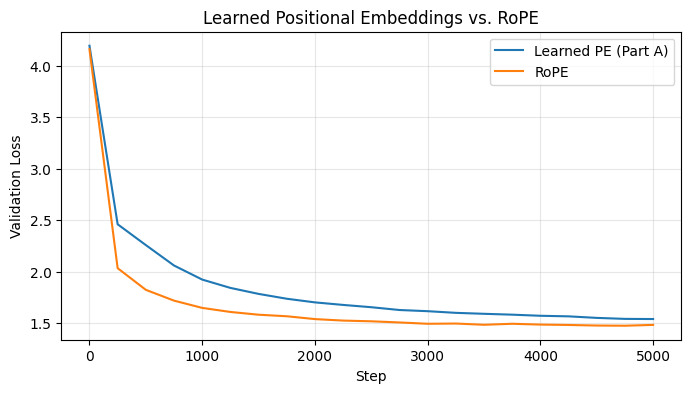

Final validation losses:
  Learned PE (Part A): 1.5400
  RoPE: 1.4830


In [42]:
# Compare learned PE (from Part A) vs RoPE
comparison_logs = {
    'Learned PE (Part A)': log,
    'RoPE': rope_log,
}
plot_ablation(comparison_logs, 'Learned Positional Embeddings vs. RoPE')

In [43]:
# Generate text from RoPE model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = rope_model.generate(context, max_new_tokens=500, temperature=0.8)
print('RoPE model generated text:')
print(decode(generated[0].tolist()))

RoPE model generated text:

Than my wife staff little father: be he will build
And tnot forward to be black? then he, modth!
Alack, break the first pain shortle lease,
That's not his restored: this is a marble,
For this sin, against the poor switting.

GLOUCESTER:
Ay, madam, and hath not unfold in his sword,
Where he did content his cheeking's globle forth,
County degreen pastient.

ROMEO:
Nay, sir.

SICINIUS:
Here he heaven does me along; and in fast shows beheld
and child that doth kill him all the people.

AUTOLYCUS:
Le
